# AnchorDepth — Demo de inferență

**Lucrare de licență** — Universitatea Politehnica Timișoara, 2026

Acest notebook rulează modelul AnchorDepth antrenat pe o imagine selectată de utilizator și produce o estimare de adâncime monoculară.  
Rezultatul este o comparație vizuală: **Imagine RGB | AnchorDepth (propus) | Depth Pro (zero-shot)**

**Utilizare:** Se rulează celulele în ordine. La Celula 3 se selectează imaginea dorită.

## 1. Inițializare

Se importă bibliotecile necesare și se configurează calea către modulele proiectului.

In [3]:
import sys, os, time
from pathlib import Path

print("Importing libraries...")
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision.transforms import ToTensor, Normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
print("✓ Base libraries loaded")

# Add project paths
ROOT = Path(os.getcwd())  # should be d:\AnchorDepth
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "training"))

print("Loading depth_pro module (this takes ~15s first time)...")
import depth_pro
print("✓ depth_pro loaded")

from train_nyu_lora import LoRALinear, apply_lora_to_encoder
print("✓ LoRA utilities loaded")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
print("\n✓ Setup complete — run next cell to load models")

Importing libraries...
✓ Base libraries loaded
Loading depth_pro module (this takes ~15s first time)...
✓ depth_pro loaded
✓ LoRA utilities loaded

Device: cpu

✓ Setup complete — run next cell to load models


## 2. Încărcarea modelelor

Se încarcă modelul **AnchorDepth** (antrenat cu metoda propusă) și, opțional, modelul **Depth Pro zero-shot** (referință de bază, fără adaptare pe KITTI).

Calea către checkpoint se modifică din variabila `CHECKPOINT`.

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================
CHECKPOINT = "checkpoints/anchordepth.pt"  # exported model (LoRA merged)
LORA_RANK = 8
LORA_ALPHA = 8.0

from depth_pro.depth_pro import DepthProConfig, DEFAULT_MONODEPTH_CONFIG_DICT

# Create config WITHOUT loading default checkpoint (we load our own)
config_no_ckpt = DepthProConfig(
    patch_encoder_preset=DEFAULT_MONODEPTH_CONFIG_DICT.patch_encoder_preset,
    image_encoder_preset=DEFAULT_MONODEPTH_CONFIG_DICT.image_encoder_preset,
    decoder_features=DEFAULT_MONODEPTH_CONFIG_DICT.decoder_features,
    fov_encoder_preset=DEFAULT_MONODEPTH_CONFIG_DICT.fov_encoder_preset,
    use_fov_head=True,
    checkpoint_uri=None,  # skip default checkpoint loading
)

# ============================================================
# Load AnchorDepth (trained)
# ============================================================
print("Loading AnchorDepth...")
model_anchor, _ = depth_pro.create_model_and_transforms(config=config_no_ckpt, device=device)

# Try loading — if it's an exported (merged) checkpoint, load directly
# If it's a training checkpoint with "depth_model" key, extract it
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
if isinstance(ckpt, dict) and "depth_model" in ckpt:
    state = ckpt["depth_model"]
    # Training checkpoint still has LoRA layers — apply them first
    apply_lora_to_encoder(model_anchor, rank=LORA_RANK, alpha=LORA_ALPHA)
else:
    state = ckpt  # exported/merged checkpoint

missing, unexpected = model_anchor.load_state_dict(state, strict=False)
model_anchor.eval()
print(f"✓ AnchorDepth loaded from: {CHECKPOINT}")
if missing:
    print(f"  (missing keys: {len(missing)} — typically fc_norm, expected)")

# ============================================================
# Load Depth Pro zero-shot (baseline for comparison)
# ============================================================
DEPTH_PRO_CKPT = "checkpoints/depth_pro.pt"

if os.path.exists(DEPTH_PRO_CKPT):
    print("Loading Depth Pro zero-shot...")
    config_zs = DepthProConfig(
        patch_encoder_preset=DEFAULT_MONODEPTH_CONFIG_DICT.patch_encoder_preset,
        image_encoder_preset=DEFAULT_MONODEPTH_CONFIG_DICT.image_encoder_preset,
        decoder_features=DEFAULT_MONODEPTH_CONFIG_DICT.decoder_features,
        fov_encoder_preset=DEFAULT_MONODEPTH_CONFIG_DICT.fov_encoder_preset,
        use_fov_head=True,
        checkpoint_uri=DEPTH_PRO_CKPT,
    )
    model_zs, _ = depth_pro.create_model_and_transforms(config=config_zs, device=device)
    model_zs.eval()
    print("✓ Depth Pro zero-shot loaded")
    HAS_ZEROSHOT = True
else:
    print(f"⚠ {DEPTH_PRO_CKPT} not found — skipping zero-shot comparison")
    print("  (Only showing AnchorDepth output)")
    model_zs = None
    HAS_ZEROSHOT = False

print("\n✓ Models ready — run next cell to select an image")

Loading AnchorDepth...


: 

## 3. Selectarea imaginii

Se deschide o fereastră de dialog pentru alegerea unei imagini RGB (JPG, PNG).

Image: C:/Users/Darius/Downloads/0000000000.png (1242x375)


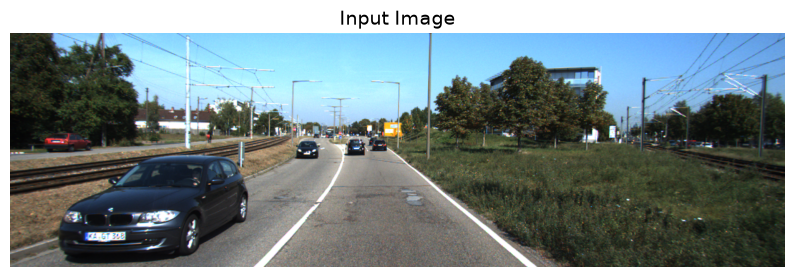

In [5]:
import tkinter as tk
from tkinter import filedialog

# Open file dialog to pick an image
root = tk.Tk()
root.withdraw()  # hide the main window
root.attributes("-topmost", True)  # bring dialog to front
IMAGE_PATH = filedialog.askopenfilename(
    title="Select an image",
    filetypes=[("Images", "*.jpg *.jpeg *.png *.bmp *.tiff"), ("All files", "*.*")]
)
root.destroy()

if not IMAGE_PATH:
    raise RuntimeError("No image selected!")

# Load and display
img = Image.open(IMAGE_PATH).convert("RGB")
print(f"Image: {IMAGE_PATH} ({img.size[0]}x{img.size[1]})")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.title("Input Image", fontsize=14)
plt.axis("off")
plt.show()

## 4. Inferență și comparație

Se rulează modelul pe imaginea selectată și se generează harta de adâncime estimată. Dacă este disponibil checkpoint-ul original Depth Pro, se afișează și rezultatul zero-shot pentru comparație.

Running AnchorDepth...
  (CPU inference takes ~2-5 minutes for this model)
  → 39.5 seconds


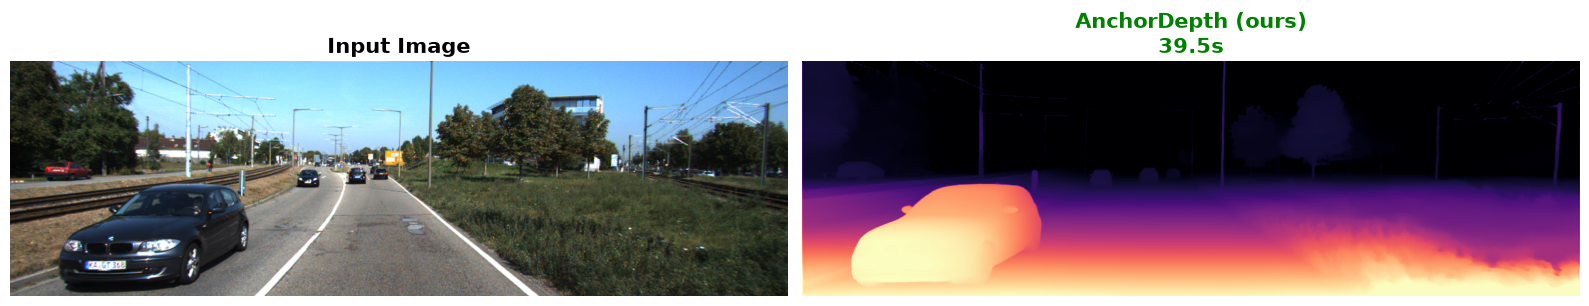


✓ Saved to figures/inference_comparison.png


In [6]:
@torch.no_grad()
def predict_depth(model, img_pil, device):
    """Run Depth Pro model on a PIL image -> (depth_map, time_ms)."""
    img_1536 = img_pil.resize((1536, 1536), Image.LANCZOS)
    norm = Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    inp = norm(ToTensor()(img_1536)).unsqueeze(0).to(device)

    if device.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.time()

    # Only use autocast on CUDA — on CPU it makes things SLOWER
    if device.type == "cuda":
        with torch.amp.autocast("cuda", dtype=torch.float16):
            canonical_inv_depth, fov_deg = model(inp)
    else:
        canonical_inv_depth, fov_deg = model(inp)

    f_px = 0.5 * 1536 / torch.tan(0.5 * torch.deg2rad(fov_deg.float()))
    inv_depth = canonical_inv_depth.float() * (1536 / f_px)
    depth = 1.0 / torch.clamp(inv_depth, min=1e-4, max=1e4)

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed_ms = (time.time() - t0) * 1000

    orig_w, orig_h = img_pil.size
    depth = F.interpolate(depth, size=(orig_h, orig_w), mode="bilinear", align_corners=False)
    return depth.squeeze().cpu().float().numpy(), elapsed_ms


def depth_to_colormap(depth, cmap="magma", clip_range=(1.0, 80.0)):
    """Convert depth map to colored image using inverse-depth for better viz."""
    d = np.clip(depth, clip_range[0], clip_range[1])
    inv = 1.0 / d
    lo, hi = np.percentile(inv, [2, 98])
    inv_norm = np.clip((inv - lo) / (hi - lo + 1e-8), 0, 1)
    colormap = plt.get_cmap(cmap)
    return (colormap(inv_norm)[:, :, :3] * 255).astype(np.uint8)


# Run AnchorDepth
print("Running AnchorDepth...")
print("  (CPU inference takes ~2-5 minutes for this model)")
depth_anchor, t_anchor = predict_depth(model_anchor, img, device)
print(f"  → {t_anchor/1000:.1f} seconds")
color_anchor = depth_to_colormap(depth_anchor)

# Run zero-shot if available
if HAS_ZEROSHOT:
    print("Running Depth Pro zero-shot...")
    depth_zs, t_zs = predict_depth(model_zs, img, device)
    print(f"  → {t_zs/1000:.1f} seconds")
    color_zs = depth_to_colormap(depth_zs)
    n_cols = 3
else:
    depth_zs, t_zs, color_zs = None, None, None
    n_cols = 2

# Plot side-by-side
fig, axes = plt.subplots(1, n_cols, figsize=(8 * n_cols, 7))

axes[0].imshow(img)
axes[0].set_title("Input Image", fontsize=15, fontweight="bold")
axes[0].axis("off")

t_label = f"{t_anchor/1000:.1f}s" if t_anchor > 1000 else f"{t_anchor:.0f}ms"
axes[1].imshow(color_anchor)
axes[1].set_title(f"AnchorDepth (ours)\n{t_label}", fontsize=15, fontweight="bold", color="green")
axes[1].axis("off")

if n_cols == 3:
    t_label_zs = f"{t_zs/1000:.1f}s" if t_zs > 1000 else f"{t_zs:.0f}ms"
    axes[2].imshow(color_zs)
    axes[2].set_title(f"Depth Pro (zero-shot)\n{t_label_zs}", fontsize=15, fontweight="bold")
    axes[2].axis("off")

plt.tight_layout()
plt.savefig("figures/inference_comparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("\n✓ Saved to figures/inference_comparison.png")

## 5. (Opțional) Salvarea hărților de adâncime

Se salvează rezultatele ca imagini individuale pentru utilizare în prezentare sau teză.

In [ ]:
# Save individual outputs for video/slides
Image.fromarray(color_anchor).save("figures/depth_anchordepth.png")
np.save("figures/depth_anchordepth_raw.npy", depth_anchor)
print("✓ Saved: figures/depth_anchordepth.png")

if HAS_ZEROSHOT:
    Image.fromarray(color_zs).save("figures/depth_zeroshot.png")
    np.save("figures/depth_zeroshot_raw.npy", depth_zs)
    print("✓ Saved: figures/depth_zeroshot.png")